# Phase 6: Semantic Matching & Ranking Demonstration

This notebook demonstrates the **Resume Ranking Engine**. We use high-dimensional neural embeddings to find the most relevant candidates for a job description without relying on exact keyword matching.

In [1]:
import sys
import os
# Add src to path for imports
sys.path.append(os.path.abspath('..'))

from src.matching.matcher import ResumeMatcher
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style("whitegrid")

## 1. Initialize the Matcher

In [2]:
matcher = ResumeMatcher(
    scaler_path="../models/scaler.pkl",
    embeddings_path="../data/embeddings/resume_embeddings.npy",
    processed_data_path="../data/processed/resumes_cleaned.csv"
)

Initializing Semantic Matcher...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## 2. Test Different Job Descriptions

Try changing the text below to see how the ranking engine responds to different roles.

In [3]:
test_jds = [
    "We are hiring a Java Developer with experience in Spring Boot and Microservices architecture.",
    "Looking for a creative Graphic Designer skilled in Adobe Photoshop, Illustrator, and branding.",
    "HR Specialist needed for talent acquisition, employee relations, and payroll management."
]

for jd in test_jds:
    print(f"\n---\nSearch Query: {jd}")
    matches = matcher.match(jd, top_k=3)
    for i, m in enumerate(matches):
        print(f"  {i+1}. [Score: {m['score']}] [Category: {m['category']}]")


---
Search Query: We are hiring a Java Developer with experience in Spring Boot and Microservices architecture.
Generating embedding for job description...
  1. [Score: 0.0824] [Category: INFORMATION-TECHNOLOGY]
  2. [Score: 0.025] [Category: CONSULTANT]
  3. [Score: -0.0009] [Category: AVIATION]

---
Search Query: Looking for a creative Graphic Designer skilled in Adobe Photoshop, Illustrator, and branding.
Generating embedding for job description...
  1. [Score: 0.1327] [Category: DESIGNER]
  2. [Score: 0.0377] [Category: DESIGNER]
  3. [Score: 0.0226] [Category: DESIGNER]

---
Search Query: HR Specialist needed for talent acquisition, employee relations, and payroll management.
Generating embedding for job description...
  1. [Score: 0.0865] [Category: HR]
  2. [Score: 0.0376] [Category: HR]
  3. [Score: 0.037] [Category: HR]


## 3. Visualization of Top-K Scores

Generating embedding for job description...


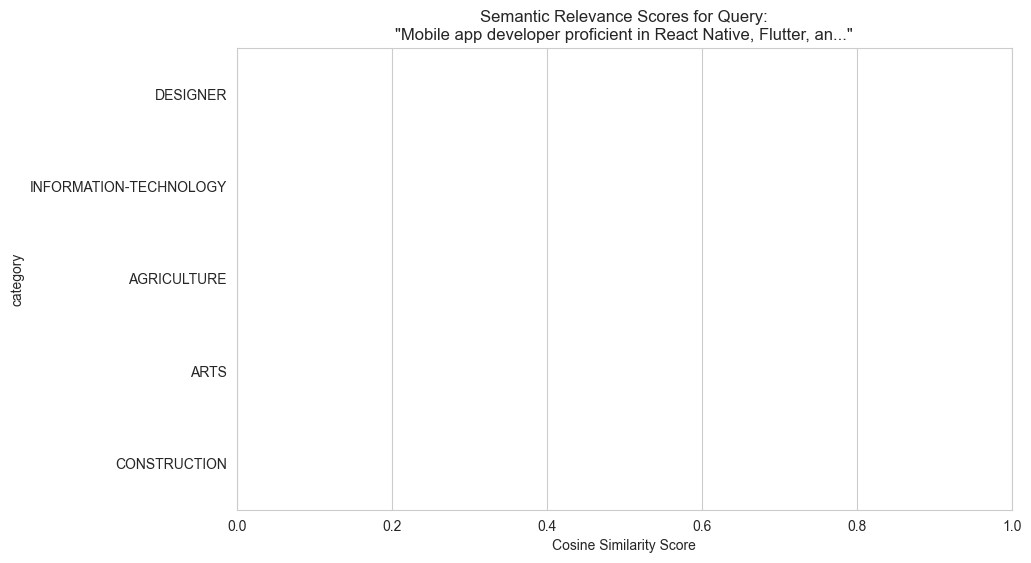

In [4]:
query = "Mobile app developer proficient in React Native, Flutter, and iOS development."
matches = matcher.match(query, top_k=10)

df_results = pd.DataFrame(matches)

plt.figure(figsize=(10, 6))
sns.barplot(data=df_results, x='score', y='category', palette='magma')
plt.title(f'Semantic Relevance Scores for Query:\n"{query[:60]}..."')
plt.xlim(0, 1)
plt.xlabel('Cosine Similarity Score')
plt.show()